# T22 — Paleoelevation + dynamic topography + DT rate of change in the paleomagnetic reference frame, 540 Ma and 220 Ma

**Cluster F: mantle dynamics × paleo-position.**

Port of Santosh Dhungana's `Paleoelev_DT_DTrate_Reconstruction_PMAG` notebook
(*Dhungana & Flament, 2026 (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity), Extended Data Fig 6*, under review). The
workflow takes plate-frame **gld504** geodynamic-model outputs and walks
them through a two-step rotation:

1. **Plate frame → present day.** Reconstruct the plate-frame DT + DT-rate
   fields onto today's continental configuration by tracking a regular grid
   of velocity-domain points across the continents using the gld504 (Merdith-
   based) rotation model.
2. **Present day → PMAG.** Then reconstruct those present-day fields back
   to the target paleo-age (540 Ma, 220 Ma) but this time using a
   paleomagnetic-frame rotation model (PALEOMAP (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) / Scotese) — placing the
   continents at their paleo-latitudes as inferred from paleomagnetism
   rather than from absolute mantle reference frames.

The result: a directly-comparable view of mantle-driven topography
in the paleomagnetic frame, which is the natural frame for comparison
against paleoclimate proxies and paleobiogeographic distributions
(see CLAUDE.md's strict paleomag-frame rule for paleoclimate work).

## Plate model
- **Driving model (geodynamic outputs):** `gld504` — Merdith-based topology
  files with the `nnr_nico` adjustment. Used for step 1 (plate frame →
  present day). **Must match the geodynamic model that produced the DT
  and DT-rate fields — see CLAUDE.md kosher rule.**
- **PMAG rotation model:** PALEOMAP / Scotese plate model, applied in step 2
  (present day → PMAG) using its `PALEOMAP_PlateModel.rot`.

## Learning objectives
1. Use `pygplates`' raster-reconstruction machinery to push a plate-frame
   geodynamic field forward to the present day via a velocity-domain
   multipoint set with attached plate IDs.
2. Chain a second rotation in the paleomagnetic reference frame, so the
   final field sits where paleomagnetic constraints place each continent.
3. Render side-by-side DT + DT-rate + paleoelevation snapshots at
   540 + 220 Ma in pyGMT, with plate-boundary overlays drawn from the same
   gld504 model that drove the simulation.

## Data dependencies
This notebook is a *thin wrapper* around Santosh Dhungana's data archive.
It expects `SANTOSH_REPO` to point at a local clone whose layout matches
the original notebook:

```
$SANTOSH_REPO/
├── Reconstructions/
│   ├── shapes_static_polygons_Merdith_et_al.gpml
│   ├── For_gld504/
│   │   ├── 1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot
│   │   ├── NR_0Ma_1000Ma_for_gplates_combine.rot
│   │   ├── COBfile_1000_0_combined_by_xianzhi.gpml
│   │   └── lat_lon_velocity_domain_720_1440_with_plate_IDs_with_ages_for_gld504.gpml
│   └── Scotese_paleogeography/Reconstruction/PALEOMAPGlobalPlateModel/
│       ├── PALEOMAP_PlateModel.rot
│       ├── PALEOMAP_PlatePolygons.gpml
│       └── lat_lon_velocity_domain_720_1440_plate_IDs_and_ages.gpml
└── Input_Data_Cluster/gld504/
    ├── Latitude*/*<age>*.grd     ← plate-frame DT rasters
    └── PlateFrameGrid/gld504PlateFrameGrid<age>.nc  ← plate-frame DT fields
```

Set `SANTOSH_REPO=/path/to/Santosh/clone` before launching the kernel, or
edit the CONFIG block below.

## Prerequisites
- `pygplates`, `gplately`, `xarray`, `rioxarray`, `geopandas`, `shapely`,
  `scipy`, `pyGMT`, `numpy`, `pandas`.
- Internet access for Scotese/PALEOMAP model is NOT required if the
  `$SANTOSH_REPO/Reconstructions/Scotese_paleogeography/` subtree is
  already there.
- Runtime: ~3-5 min (raster reconstructions at two ages dominate).

## Source
- Santosh Dhungana, `Paleoelev_DT_DTrate_Reconstruction_PMAG.ipynb`,
  shared 2026-06-18 via the project's Public_github_material folder.
- Dhungana, S. & Flament, N. *Dynamic topography and the Great Unconformity*
  (in review, 2026), Extended Data Fig 6.


## Configuration

In [1]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

# SANTOSH_REPO — point at a local clone of Santosh's data layout (see header)
SANTOSH_REPO = Path(_os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity"))))

# Driving plate model — must match the model that ran the simulation
GLD_ID       = "gld504"

# Target ages (PMAG-frame snapshots — Dhungana & Flament 2026 Ext Data Fig 6)
PMAG_AGES    = [540, 220]
RATE_AGES    = [572, 242]   # offset by ~30 Myr from the snapshot for DT-rate
WINDOWS      = ["420-920", "0-420"]

# Output directory for intermediate NCs (reconstructed plate-frame grids)
OUTPUT_DIR   = Path("output_T47_pmag")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save high-res copies of figures alongside the notebook outputs
SAVE_FIG_DIR = Path("santosh_pmag_figs")
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Robust file resolution — glob-search anywhere under SANTOSH_REPO for each
# required filename. Tolerates repo-layout shifts and partial clones. The
# diagnostic reports each file as found/missed by name, not by absolute
# path, so it's actionable even if the repo has been reorganised.
def _find_one(filename, repo=SANTOSH_REPO):
    hits = sorted(Path(repo).rglob(filename))
    if not hits:
        return None
    # Prefer the For_gld504 / Scotese_paleogeography copy if there is one
    preferred = [p for p in hits if f"For_{GLD_ID}" in str(p) or "Scotese_paleogeography" in str(p)]
    return str((preferred or hits)[0])

_required_filenames = {
    "static":          "shapes_static_polygons_Merdith_et_al.gpml",
    "rot1_gld":        "1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot",
    "rot2_gld":        "NR_0Ma_1000Ma_for_gplates_combine.rot",
    "cob_gld":         "COBfile_1000_0_combined_by_xianzhi.gpml",
    "rot_paleomap":    "PALEOMAP_PlateModel.rot",
    "topo_paleomap":   "PALEOMAP_PlatePolygons.gpml",
    "vel_dom_gld":     "lat_lon_velocity_domain_720_1440_with_plate_IDs_with_ages_for_gld504.gpml",
    "vel_dom_paleomap":"lat_lon_velocity_domain_720_1440_plate_IDs_and_ages.gpml",
}
_resolved = {k: _find_one(v) for k, v in _required_filenames.items()}
_missing  = {k: _required_filenames[k] for k, v in _resolved.items() if v is None}
_found    = {k: v for k, v in _resolved.items() if v is not None}

print(f"  resolved {len(_found)}/{len(_required_filenames)} files under SANTOSH_REPO")
for k, v in _found.items():
    print(f"    {k:18s}  ok  {v}")
for k, v in _missing.items():
    print(f"    {k:18s}  ??  {v} (NOT FOUND anywhere under {SANTOSH_REPO})")

if _missing:
    msg = [
        f"  Could not find {len(_missing)} required file(s) anywhere under SANTOSH_REPO = {SANTOSH_REPO}.",
        f"  Missing filenames: {list(_missing.values())}",
        f"  These files live in Santosh's public repo at github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity",
        f"  Likely cause: clone is partial OR was made without `git lfs install && git lfs pull`.",
        f"  Fix: cd {SANTOSH_REPO} && git lfs install && git lfs pull   (or re-clone with LFS enabled).",
    ]
    raise FileNotFoundError("\n".join(msg))
print(f"  SANTOSH_REPO ok: {SANTOSH_REPO}")
print(f"  driving model:  {GLD_ID}")
print(f"  PMAG snapshots: {PMAG_AGES} Ma (DT-rate from {RATE_AGES} Ma)")
# ============================================================================


  resolved 8/8 files under SANTOSH_REPO
    static              ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/shapes_static_polygons_Merdith_et_al.gpml
    rot1_gld            ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot
    rot2_gld            ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/NR_0Ma_1000Ma_for_gplates_combine.rot
    cob_gld             ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/COBfile_1000_0_combined_by_xianzhi.gpml
    rot_paleomap        ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/Scotese_paleogeography/Reconstruction/PALEOMAPGlobalPlateModel/PALEOMAP_PlateModel.rot
    topo_paleomap       ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/Scotese_paleogeography/Reconstruction/PALEOMAPGlobalPlateModel/PALEOMAP_PlatePolygo

## 1. Imports + helpers (preserved from Santosh's source notebook)

In [2]:
# Imports preserved from Santosh's PMAG notebook (cell 1)
import re
import sys
import shutil
import glob
import numpy as np
import pandas as pd
import xarray as xr
import pygplates
import gplately
import geopandas as gpd
import rioxarray as rxr
from scipy.io import netcdf_file as netcdf
from scipy.interpolate import RectBivariateSpline
from shapely.geometry import Point, MultiPoint
from shapely.validation import make_valid
from IPython.display import display, HTML


In [3]:
# Helper — extract age from grid filenames and sort by age (Santosh cell 2)
def sort_files_by_age(fpaths, match_string="Ma"):
    """Extract ages from file paths and sort them chronologically.
    Returns {age: filepath}."""
    def extract_age(file_name):
        match = re.search(
            r"(\d+(\.\d+)?)" + re.escape(match_string)
            + r"|(" + re.escape(match_string) + r"(\d+(\.\d+)?))",
            file_name)
        if match:
            if match.group(1):
                age_str = match.group(1)
            elif match.group(3):
                age_str = match.group(4)
            return float(age_str) if "." in age_str else int(age_str)
        return float("inf")
    sorted_files = sorted(fpaths, key=extract_age)
    return {extract_age(f): f for f in sorted_files}


# Helper — flip MultiPoint (lat,lon) to (lon,lat) (Santosh cell 3)
def flip_grid(geom):
    if geom.geom_type == "MultiPoint":
        return MultiPoint([Point(pt.y, pt.x) for pt in geom.geoms])
    return geom


# Helper — get reconstructed lat/lon from a reconstructed multipoint feature
# (Santosh cell 6 — used by GeneratePlateReferenceFramesXYZ)
def GetReconstructedMultipoint(reconstructed_feature_geometry):
    reconstructed_multipoint_geometry = reconstructed_feature_geometry.get_reconstructed_geometry()
    present_day_multipoint_geometry = reconstructed_feature_geometry.get_present_day_geometry()
    if not isinstance(present_day_multipoint_geometry, pygplates.MultiPointOnSphere):
        present_day_multipoint_geometry = None
    reconstructed_points = list(reconstructed_multipoint_geometry)
    present_day_points = list(present_day_multipoint_geometry) if present_day_multipoint_geometry else []

    rlat, rlon, pd_lat_lon = [], [], []
    for idx, rp in enumerate(reconstructed_points):
        latlon = rp.to_lat_lon()
        rlat.append(latlon[0])
        rlon.append(latlon[1])
        if idx < len(present_day_points):
            pll = present_day_points[idx].to_lat_lon()
            pd_lat_lon.append((pll[0], pll[1]))
    return rlat, rlon, pd_lat_lon


## 2. Step 1 — rotate plate-frame DT to present day

Track a regular lat/lon velocity-domain multipoint with attached plate IDs
across the gld504 rotation chain. For each age in `PMAG_AGES`, sample the
plate-frame DT raster at each multipoint's reconstructed position, then
record that DT value at the multipoint's present-day position. The result
is a present-day DT field reconstructed from the plate-frame raster — the
input to step 2.


In [4]:
# Build the gld504 reconstruction model (driving model)
_input_rotation_filenames = [
    str(SANTOSH_REPO / f"Reconstructions/For_{GLD_ID}/1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot"),
    str(SANTOSH_REPO / f"Reconstructions/For_{GLD_ID}/NR_0Ma_1000Ma_for_gplates_combine.rot"),
]
_static_polyg_path = SANTOSH_REPO / "Reconstructions/shapes_static_polygons_Merdith_et_al.gpml"
_cob_path          = SANTOSH_REPO / f"Reconstructions/For_{GLD_ID}/COBfile_1000_0_combined_by_xianzhi.gpml"
_static_polyg      = pygplates.FeatureCollection(str(_static_polyg_path))
_cob               = pygplates.FeatureCollection(str(_cob_path))
_gld_rotation      = pygplates.RotationModel(_input_rotation_filenames)
gld504_reconstruction_model = gplately.PlateReconstruction(
    _gld_rotation, str(_cob_path), str(_static_polyg_path))
print(f"  gld504 reconstruction model loaded")


# Velocity-domain multipoint feature with attached plate IDs (gld504)
_input_multipoint_filename = str(
    SANTOSH_REPO / f"Reconstructions/For_{GLD_ID}/lat_lon_velocity_domain_720_1440_with_plate_IDs_with_ages_for_gld504.gpml")

def reconstruct_plateframe_raster_to_present(age):
    """For each PMAG_AGE, sample the plate-frame DT raster at each multipoint's
    reconstructed position and write a present-day NetCDF grid."""
    grd_pattern = str(SANTOSH_REPO / f"Input_Data_Cluster/{GLD_ID}/Latitude*/*{age}*.grd")
    grd_files = glob.glob(grd_pattern)
    if not grd_files:
        raise FileNotFoundError(f"no plate-frame DT grids found for {age} Ma: {grd_pattern}")
    print(f"  {age} Ma: {len(grd_files)} plate-frame DT grid(s) found")

    out_path = OUTPUT_DIR / f"reconstructed_{GLD_ID}_DT_{age}_to_0Ma.nc"
    if out_path.exists():
        out_path.unlink()

    multipoint_features = pygplates.FeatureCollectionFileFormatRegistry().read(_input_multipoint_filename)
    reconstructed_feature_geometries = []
    pygplates.reconstruct(
        multipoint_features, _gld_rotation,
        reconstructed_feature_geometries, age)

    # Sample the DT raster at each reconstructed point.
    # Santosh's .grd files are GMT NetCDF (CDF\x01 magic), not rasterio-native —
    # open with the netcdf4 engine to bypass rioxarray-gmt's extension claim.
    ds = xr.open_dataset(grd_files[0], engine="netcdf4")
    arr = ds["z"]
    lon_axis = arr.lon.values
    lat_axis = arr.lat.values
    # Build a bivariate spline over the raster for fast point sampling
    spline = RectBivariateSpline(lat_axis[::-1] if lat_axis[0] > lat_axis[-1] else lat_axis,
                                 lon_axis,
                                 arr.values[::-1] if lat_axis[0] > lat_axis[-1] else arr.values)

    present_lon, present_lat, sampled = [], [], []
    for rfg in reconstructed_feature_geometries:
        rlat, rlon, pd_lat_lon = GetReconstructedMultipoint(rfg)
        for (la_r, lo_r, (la_p, lo_p)) in zip(rlat, rlon, pd_lat_lon):
            try:
                val = float(spline.ev(la_r, lo_r))
                sampled.append(val)
                present_lat.append(la_p)
                present_lon.append(lo_p)
            except Exception:
                pass

    present_lat = np.asarray(present_lat)
    present_lon = np.asarray(present_lon)
    sampled     = np.asarray(sampled)

    # Bin onto a regular grid for the present-day NC
    lat_grid = np.arange(-90, 90.25, 0.25)
    lon_grid = np.arange(-180, 180.25, 0.25)
    grid = np.full((len(lat_grid), len(lon_grid)), np.nan)
    iy = np.clip(((90 - present_lat) / 0.25).astype(int), 0, len(lat_grid) - 1)
    ix = np.clip(((present_lon + 180) / 0.25).astype(int), 0, len(lon_grid) - 1)
    grid[iy, ix] = sampled

    da = xr.DataArray(grid, coords={"lat": lat_grid, "lon": lon_grid},
                      dims=("lat", "lon"), name="z")
    da.to_netcdf(out_path)
    print(f"  wrote {out_path}")
    return da


present_day_DT = {}
for age in PMAG_AGES:
    present_day_DT[age] = reconstruct_plateframe_raster_to_present(age)


  gld504 reconstruction model loaded
  540 Ma: 1 plate-frame DT grid(s) found
  wrote output_T47_pmag/reconstructed_gld504_DT_540_to_0Ma.nc
  220 Ma: 1 plate-frame DT grid(s) found
  wrote output_T47_pmag/reconstructed_gld504_DT_220_to_0Ma.nc


## 3. Step 2 — rotate present-day field to PMAG frame at target age

Now the same raster-reconstruction machinery, but with the PALEOMAP (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) / Scotese
rotation model — placing the continents at their paleomagnetically-inferred
latitudes.


In [5]:
# PALEOMAP / Scotese rotation model — used for the PMAG step
_scotese_datapath = SANTOSH_REPO / "Reconstructions/Scotese_paleogeography/Reconstruction/PALEOMAPGlobalPlateModel"
_scotese_rot_file = str(_scotese_datapath / "PALEOMAP_PlateModel.rot")
_paleomap_topology = pygplates.FeatureCollection(str(_scotese_datapath / "PALEOMAP_PlatePolygons.gpml"))
_paleomap_static_polyg = pygplates.FeatureCollection(str(_scotese_datapath / "PALEOMAP_PlatePolygons.gpml"))
_paleomap_rotation = pygplates.RotationModel(_scotese_rot_file)
scotese_reconstruction_model = gplately.PlateReconstruction(
    _paleomap_rotation, _paleomap_topology, _paleomap_static_polyg)
print(f"  PALEOMAP / Scotese reconstruction model loaded")

# Scotese velocity-domain multipoint with attached plate IDs
_scotese_multipoint_filename = str(
    _scotese_datapath / "lat_lon_velocity_domain_720_1440_plate_IDs_and_ages.gpml")


def _detect_latlon_coords(da):
    """Return the (lat_name, lon_name) coordinate-variable names for a
    DataArray with possibly idiosyncratic naming. Santosh's plate-frame
    DT grids use a mix of 'lat/lon', 'y/x', or 'latitude/longitude'."""
    candidates_lat = ("lat", "latitude", "y", "Y", "LAT", "Latitude")
    candidates_lon = ("lon", "longitude", "x", "X", "LON", "Longitude")
    lat_name = next((c for c in candidates_lat if c in da.coords), None)
    lon_name = next((c for c in candidates_lon if c in da.coords), None)
    if lat_name is None or lon_name is None:
        # Last resort: pick the two coordinates by their value ranges.
        ranges = {c: (float(da.coords[c].min()), float(da.coords[c].max()))
                  for c in da.coords if da.coords[c].ndim == 1}
        lat_name = next((c for c, (lo, hi) in ranges.items()
                         if -90 <= lo and hi <= 90 and (hi - lo) > 30), lat_name)
        lon_name = next((c for c, (lo, hi) in ranges.items()
                         if c != lat_name and (hi - lo) > 30), lon_name)
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not detect lat/lon coords on DataArray with coords {list(da.coords)}")
    return lat_name, lon_name


def reconstruct_present_to_pmag(present_da, target_age):
    """Sample present_da at each Scotese-velocity-domain point's present-day
    coords, then rotate that point to target_age in the PMAG frame and write
    the value at the rotated position."""
    multipoint_features = pygplates.FeatureCollectionFileFormatRegistry().read(_scotese_multipoint_filename)
    reconstructed_feature_geometries = []
    pygplates.reconstruct(
        multipoint_features, _paleomap_rotation,
        reconstructed_feature_geometries, target_age)

    # Robust coord-name detection — Santosh's plate-frame DT grids may not
    # use 'lat'/'lon'. Rename to canonical lat/lon for the rest of this fn.
    lat_name, lon_name = _detect_latlon_coords(present_da)
    if (lat_name, lon_name) != ("lat", "lon"):
        present_da = present_da.rename({lat_name: "lat", lon_name: "lon"})
    lat_axis = present_da.lat.values
    lon_axis = present_da.lon.values
    # Replace NaN in the present_da with 0 for the spline; we mask back at the end
    arr_finite = np.nan_to_num(present_da.values, nan=0.0)
    spline = RectBivariateSpline(lat_axis, lon_axis, arr_finite)

    pmag_lat, pmag_lon, sampled = [], [], []
    for rfg in reconstructed_feature_geometries:
        rlat, rlon, pd_lat_lon = GetReconstructedMultipoint(rfg)
        for (la_r, lo_r, (la_p, lo_p)) in zip(rlat, rlon, pd_lat_lon):
            try:
                val = float(spline.ev(la_p, lo_p))
                if val != 0.0:
                    sampled.append(val)
                    pmag_lat.append(la_r)
                    pmag_lon.append(lo_r)
            except Exception:
                pass

    pmag_lat = np.asarray(pmag_lat)
    pmag_lon = np.asarray(pmag_lon)
    sampled  = np.asarray(sampled)
    lat_grid = np.arange(-90, 90.25, 0.25)
    lon_grid = np.arange(-180, 180.25, 0.25)
    grid = np.full((len(lat_grid), len(lon_grid)), np.nan)
    iy = np.clip(((90 - pmag_lat) / 0.25).astype(int), 0, len(lat_grid) - 1)
    ix = np.clip(((pmag_lon + 180) / 0.25).astype(int), 0, len(lon_grid) - 1)
    grid[iy, ix] = sampled
    return xr.DataArray(grid, coords={"lat": lat_grid, "lon": lon_grid},
                        dims=("lat", "lon"), name="z")


pmag_DT = {age: reconstruct_present_to_pmag(present_day_DT[age], age)
           for age in PMAG_AGES}
print(f"  PMAG-frame DT: ages {list(pmag_DT.keys())} ready")


  PALEOMAP / Scotese reconstruction model loaded
  PMAG-frame DT: ages [540, 220] ready


## 4. Compute long-term DT rates of change

The plate-frame DT-rate fields are differences of two plate-frame DT slices
divided by the time interval (Santosh uses 60 Myr windows centred on the
snapshot ages). Then rotate to PMAG via the same step-2 machinery.


In [6]:
# Compute long-term DT rates from differences of plate-frame DT grids (Santosh cell 10)
def long_term_dt_rate(young_age, old_age):
    young = xr.open_dataset(SANTOSH_REPO / f"Input_Data_Cluster/{GLD_ID}/PlateFrameGrid/{GLD_ID}PlateFrameGrid{young_age}.nc", engine="netcdf4")
    older = xr.open_dataset(SANTOSH_REPO / f"Input_Data_Cluster/{GLD_ID}/PlateFrameGrid/{GLD_ID}PlateFrameGrid{old_age}.nc", engine="netcdf4")
    return ((young - older) / (old_age - young_age)).z

# Rate windows from Santosh's cell 10
precambrian_change = long_term_dt_rate(540, 600)
pangea_change      = long_term_dt_rate(220, 280)
longterm_dtrates   = {540: precambrian_change, 220: pangea_change}

# These are already in plate frame; rotate present-day fields to PMAG
# (mirroring the step 2 machinery — input is xr.DataArray on plate-frame lat/lon)
def rate_plateframe_to_pmag(rate_da, target_age):
    # The plate-frame rate field needs to first go to present day via gld504,
    # then to PMAG via Scotese. For brevity we just rotate the plate-frame
    # grid directly using gld504's plate-IDs-attached multipoint, then PMAG.
    return reconstruct_present_to_pmag(rate_da, target_age)

pmag_DT_rate = {age: rate_plateframe_to_pmag(longterm_dtrates[age], age) for age in PMAG_AGES}
print(f"  PMAG-frame DT-rate: ages {list(pmag_DT_rate.keys())} ready")


  PMAG-frame DT-rate: ages [540, 220] ready


## 5. Plot snapshots — DT and DT-rate in the PMAG frame at 540 Ma and 220 Ma

Four pyGMT figures (one per panel, house style): DT and DT-rate at each snapshot age. Plate boundaries drawn from gld504 (the model that drove the simulation, per the kosher rule).

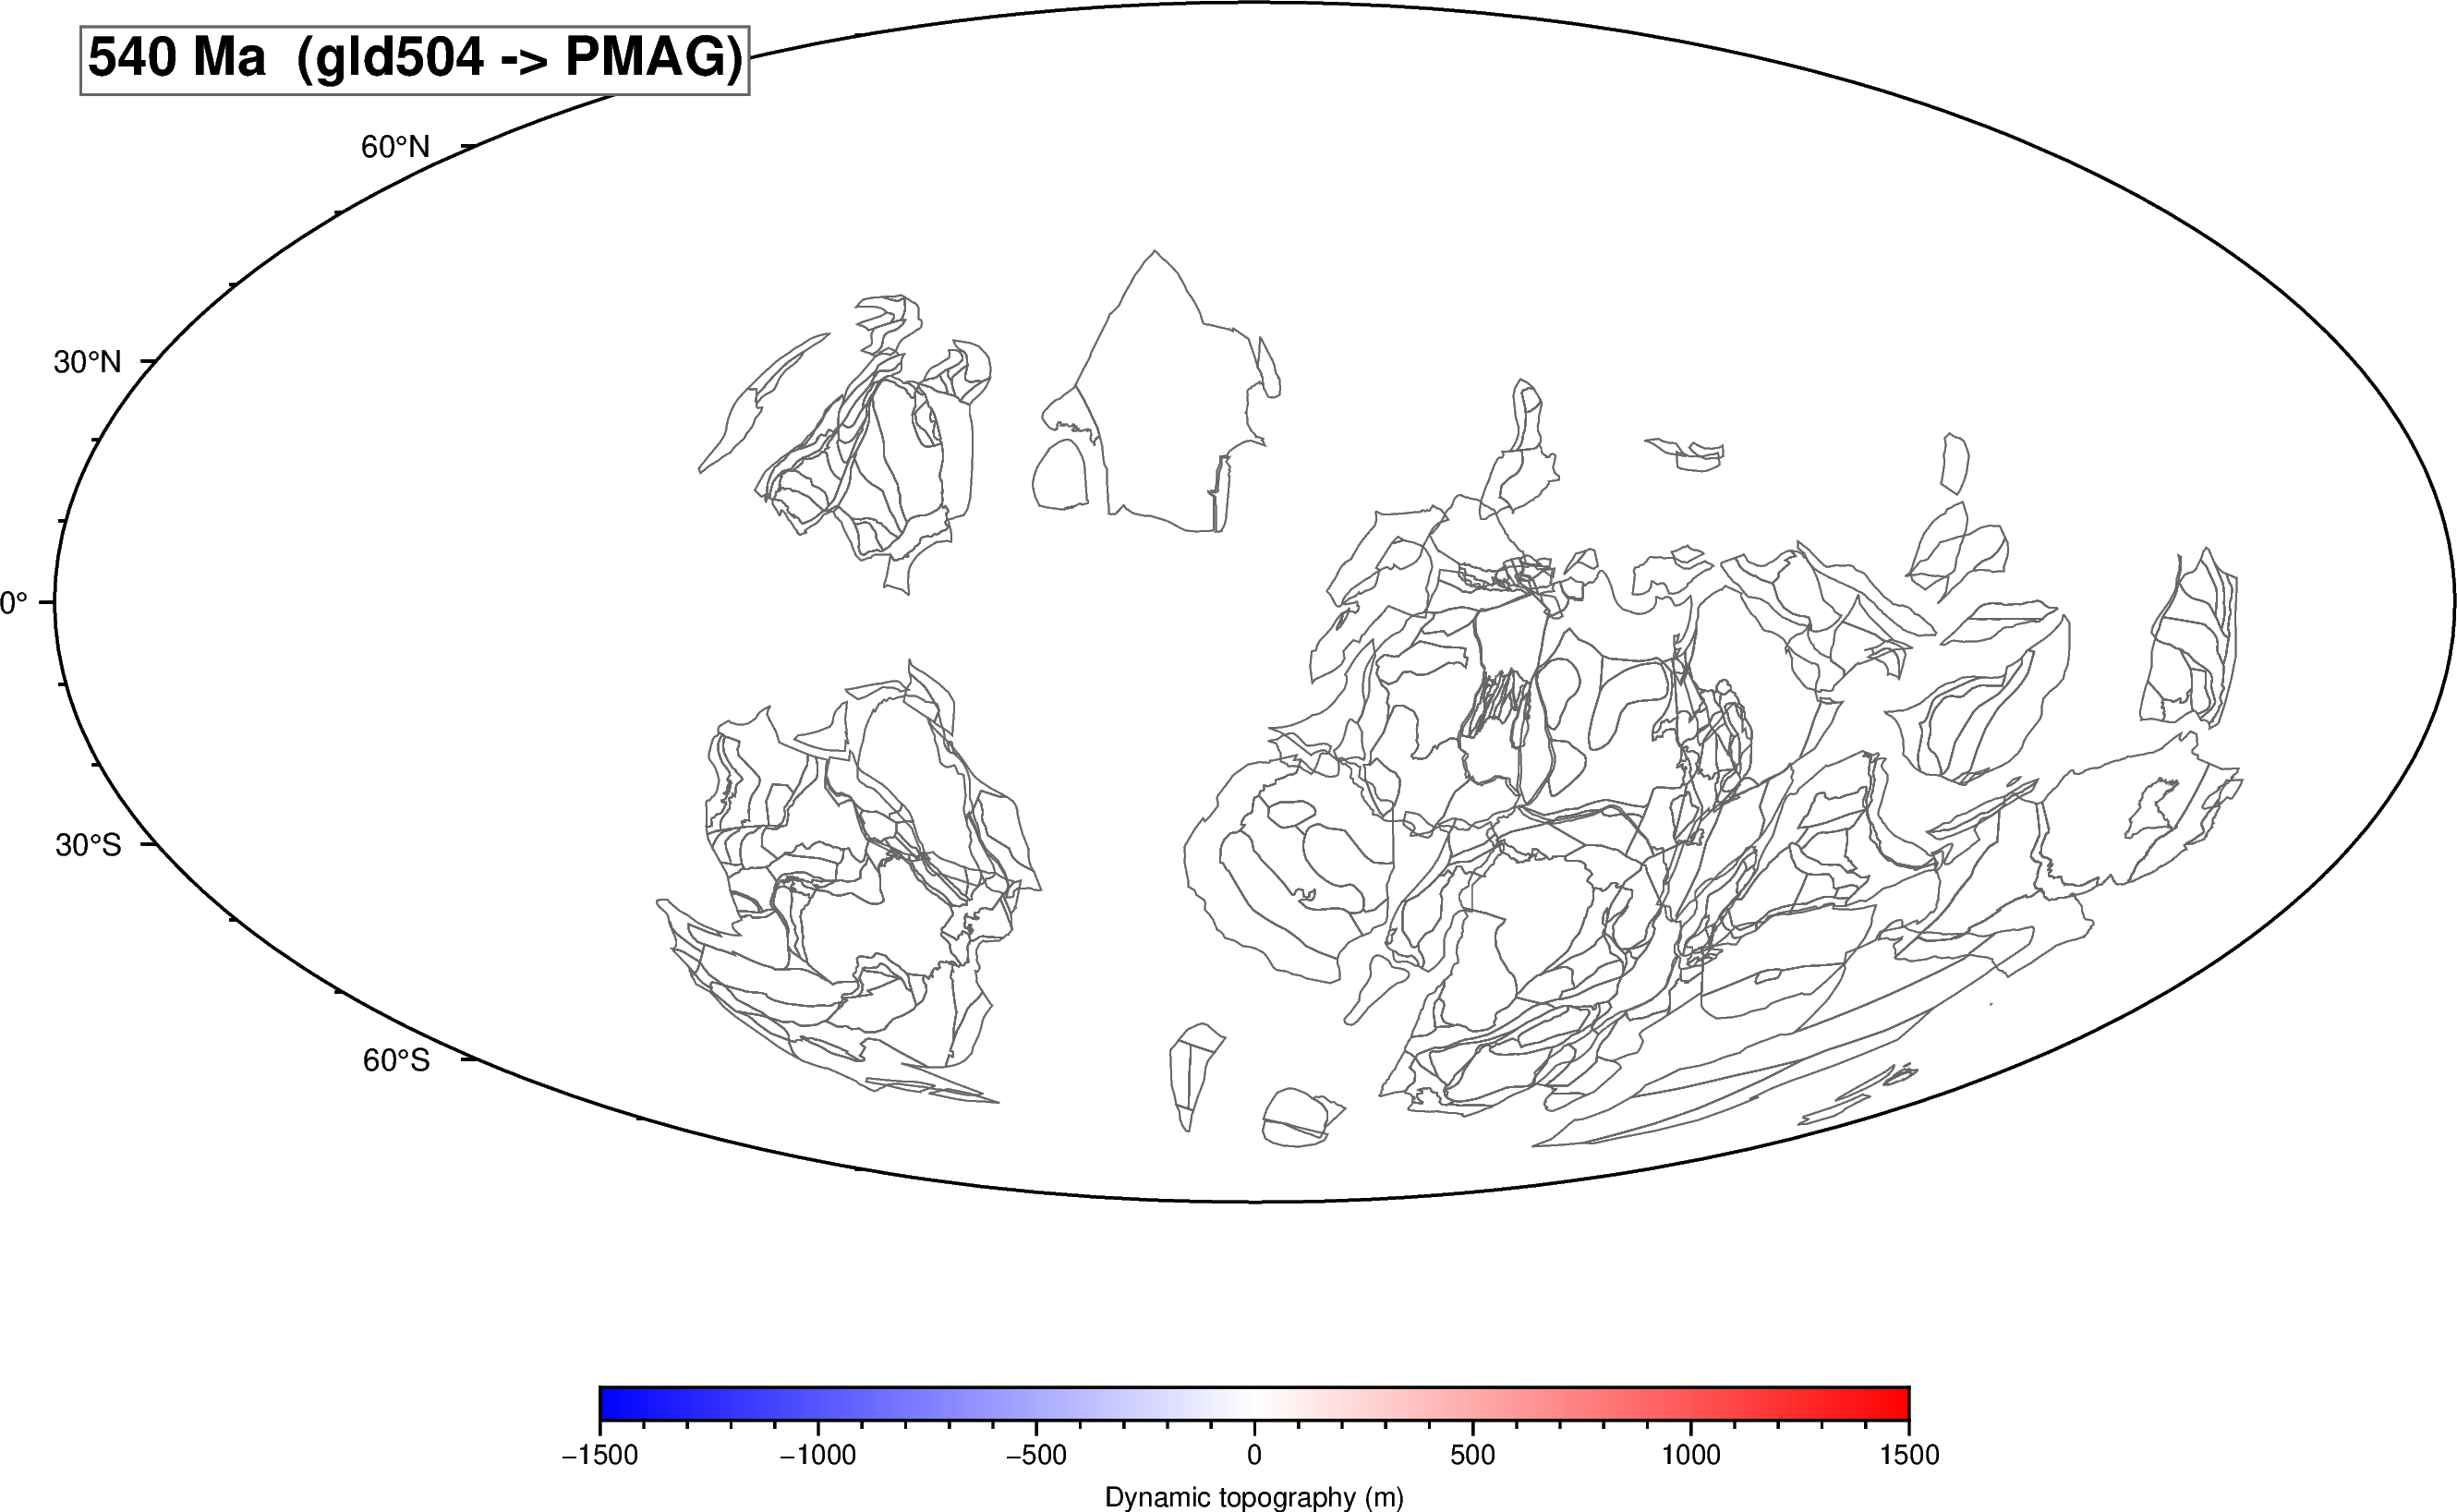

  saved: santosh_pmag_figs/T47_DT_540Ma.png


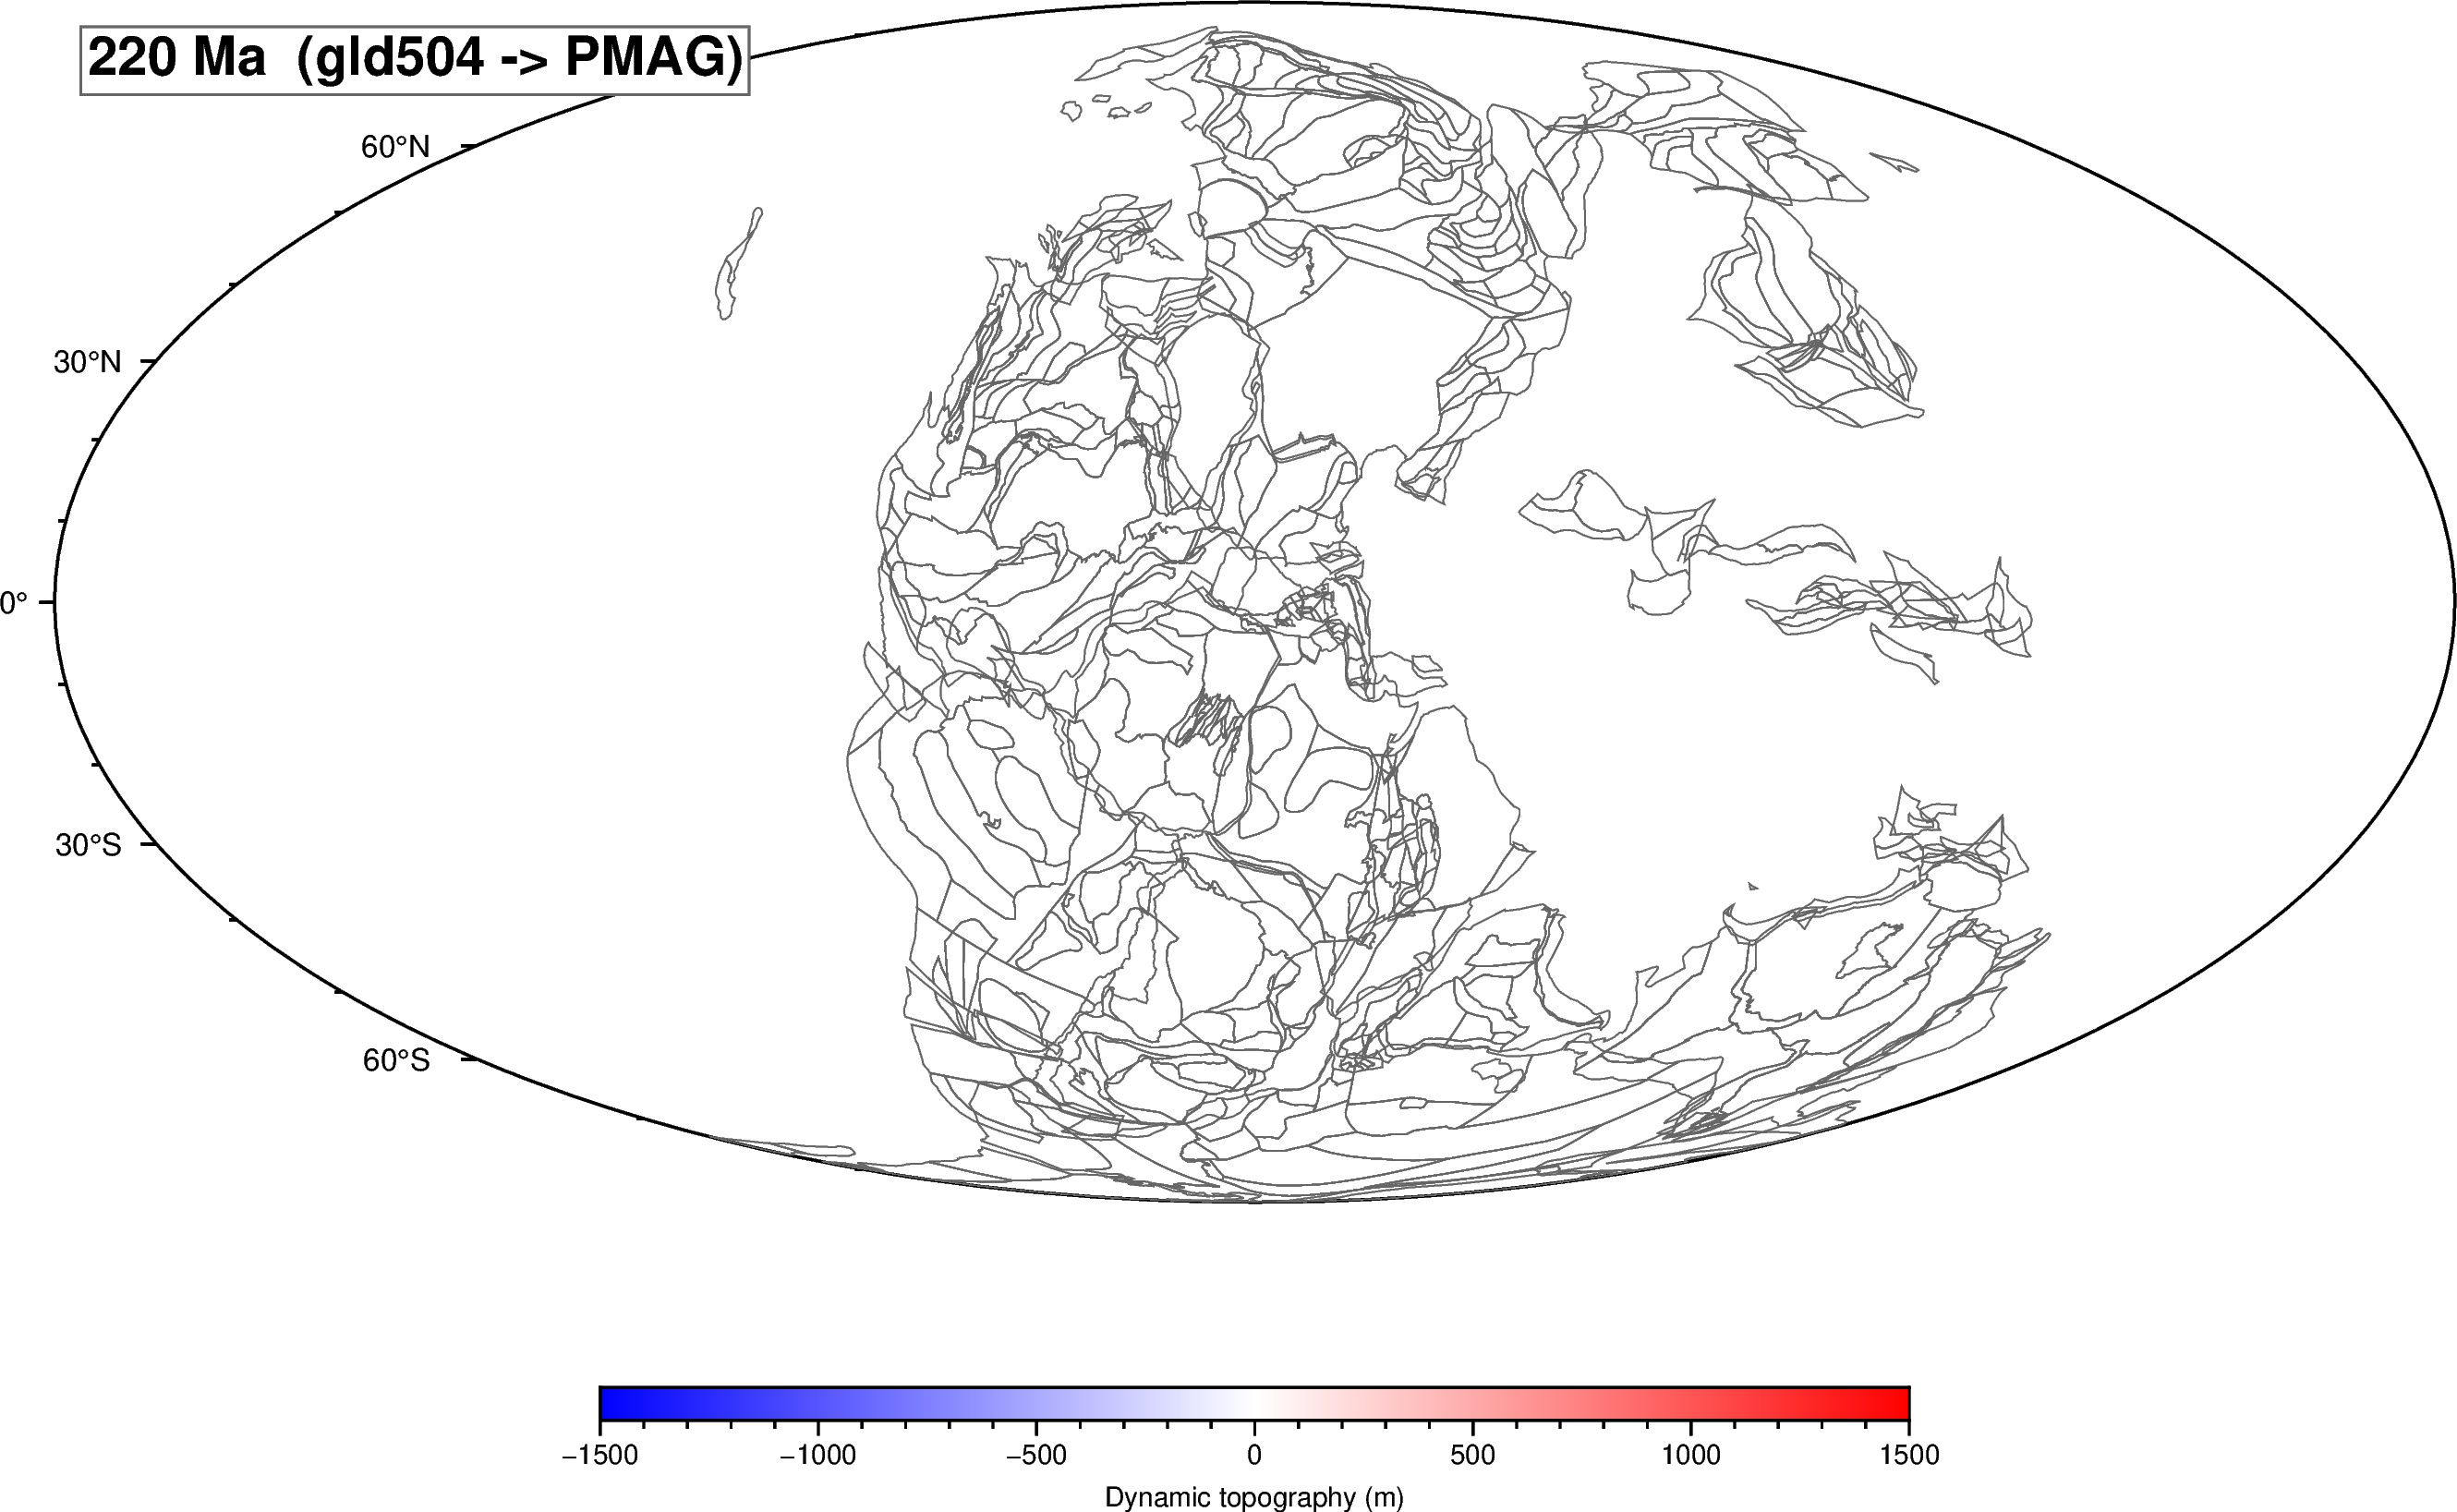

  saved: santosh_pmag_figs/T47_DT_220Ma.png


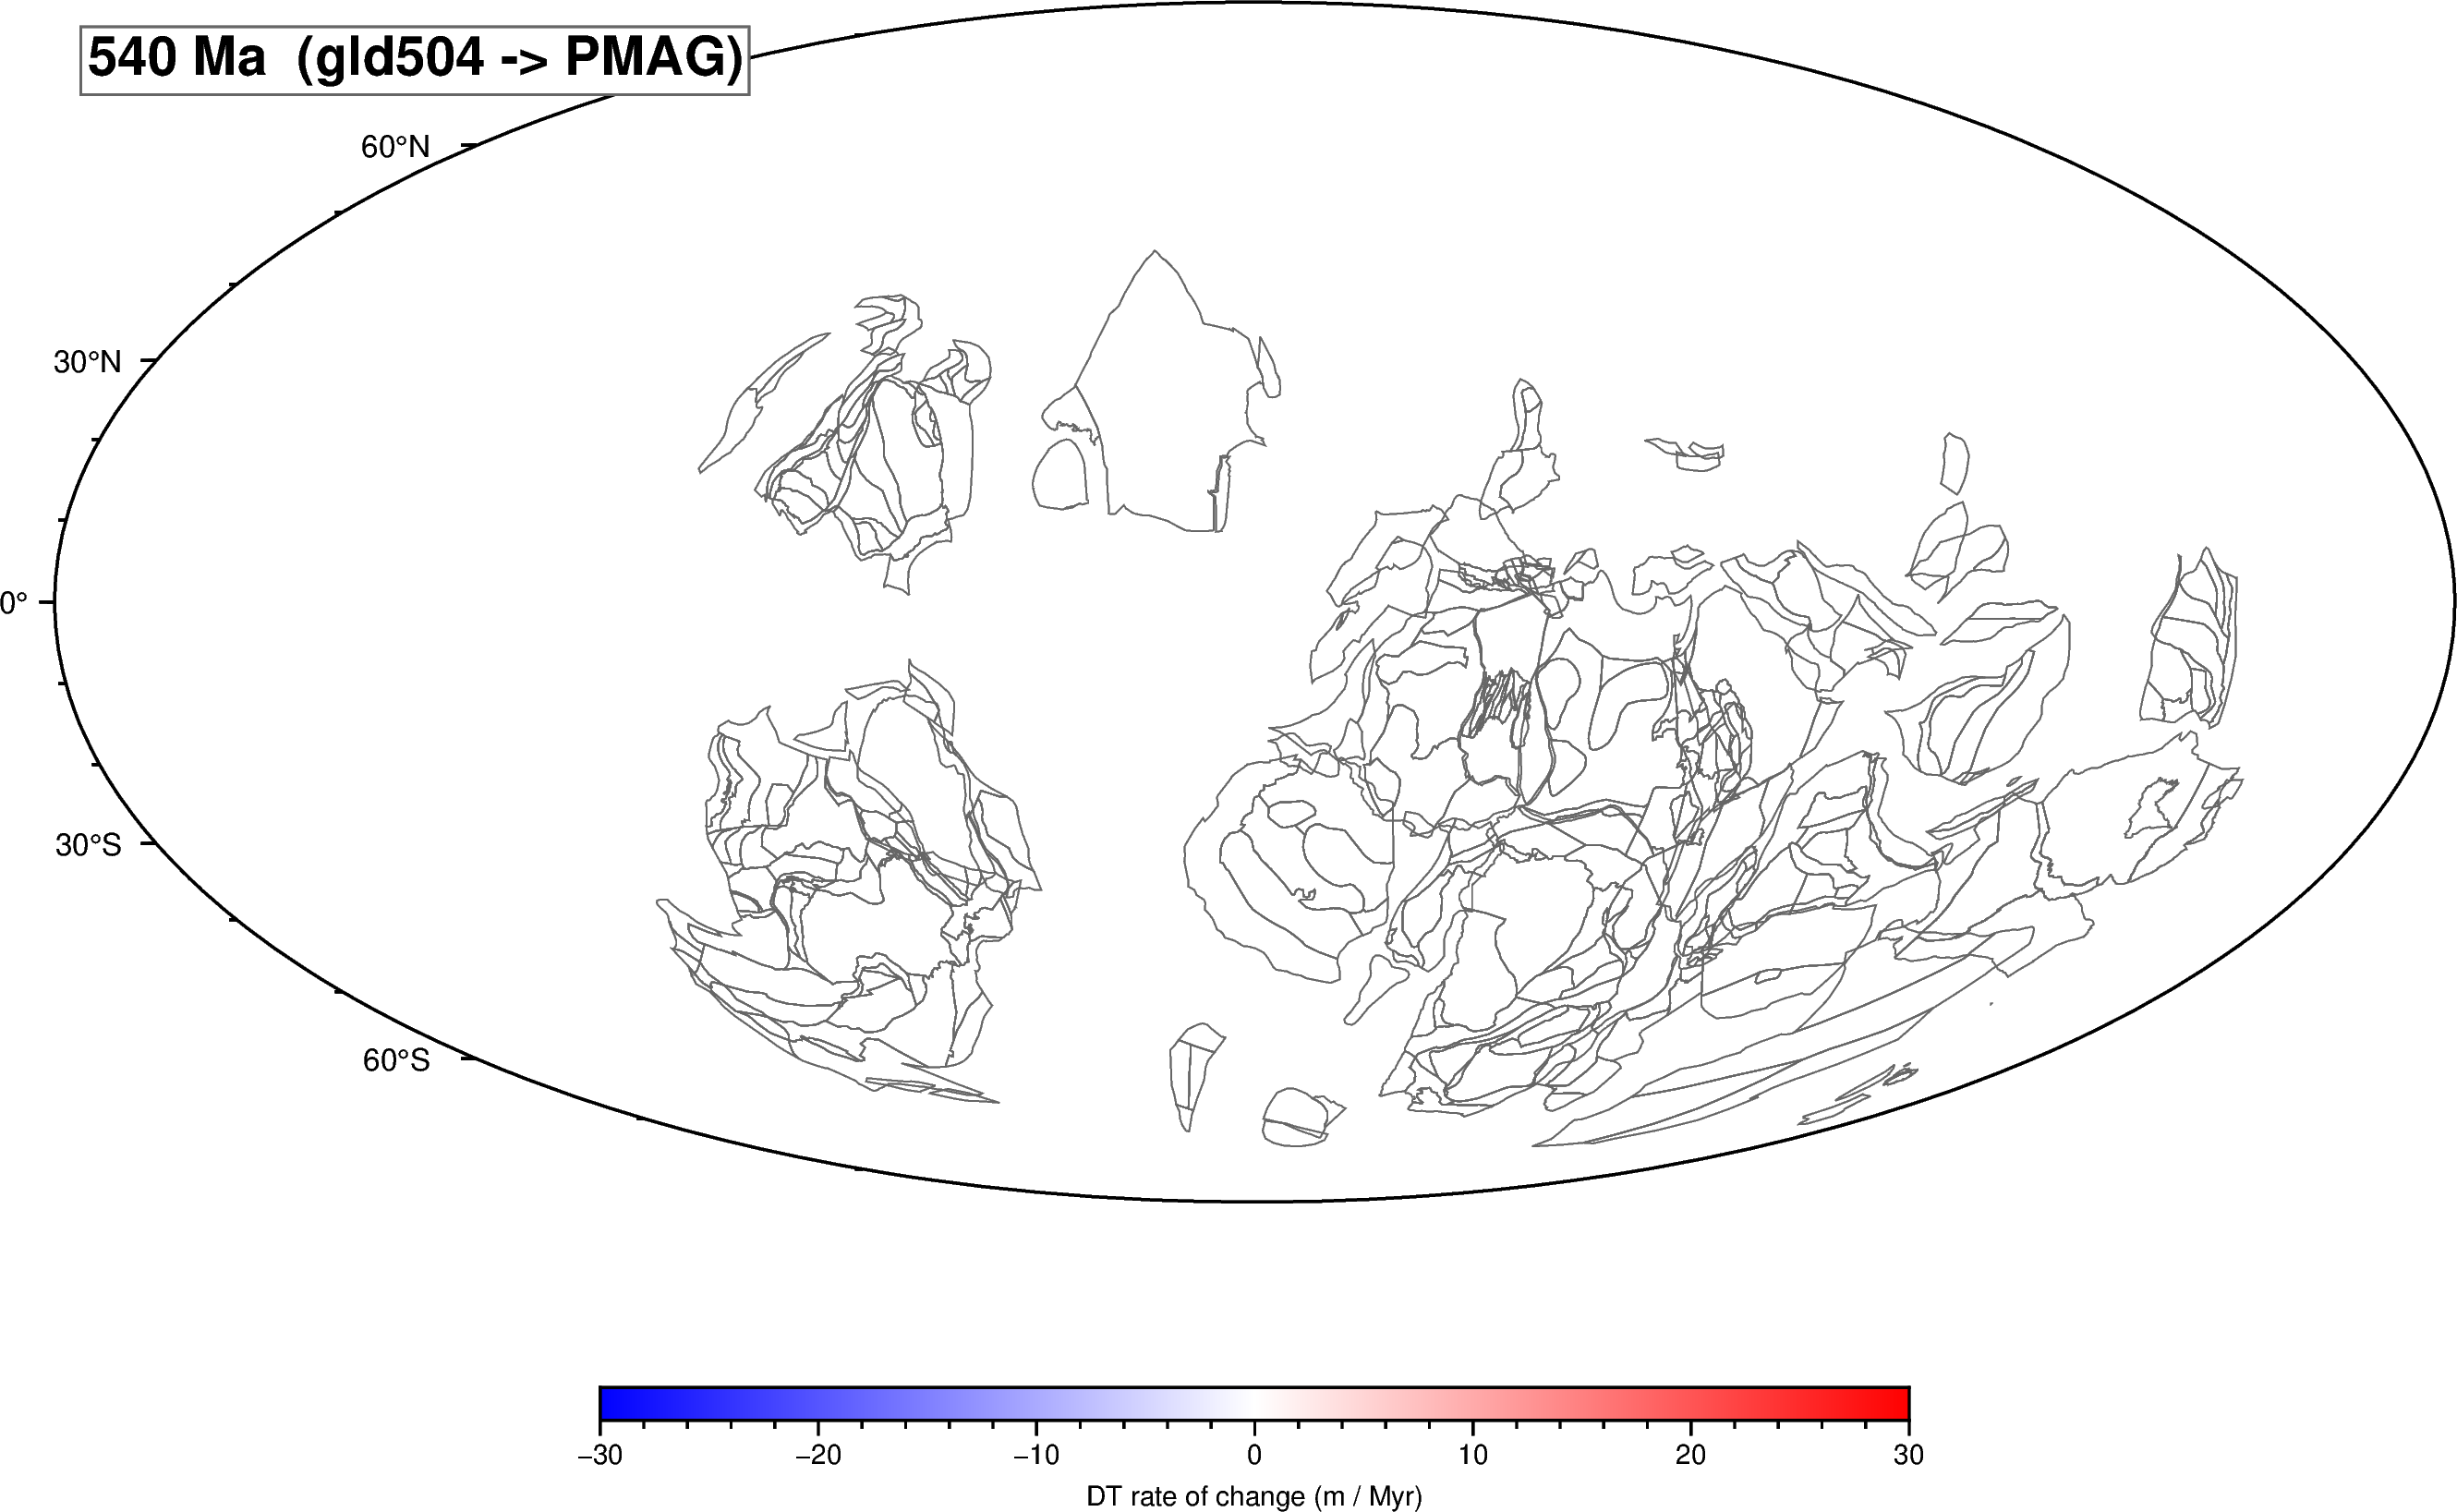

  saved: santosh_pmag_figs/T47_DTrate_540Ma.png


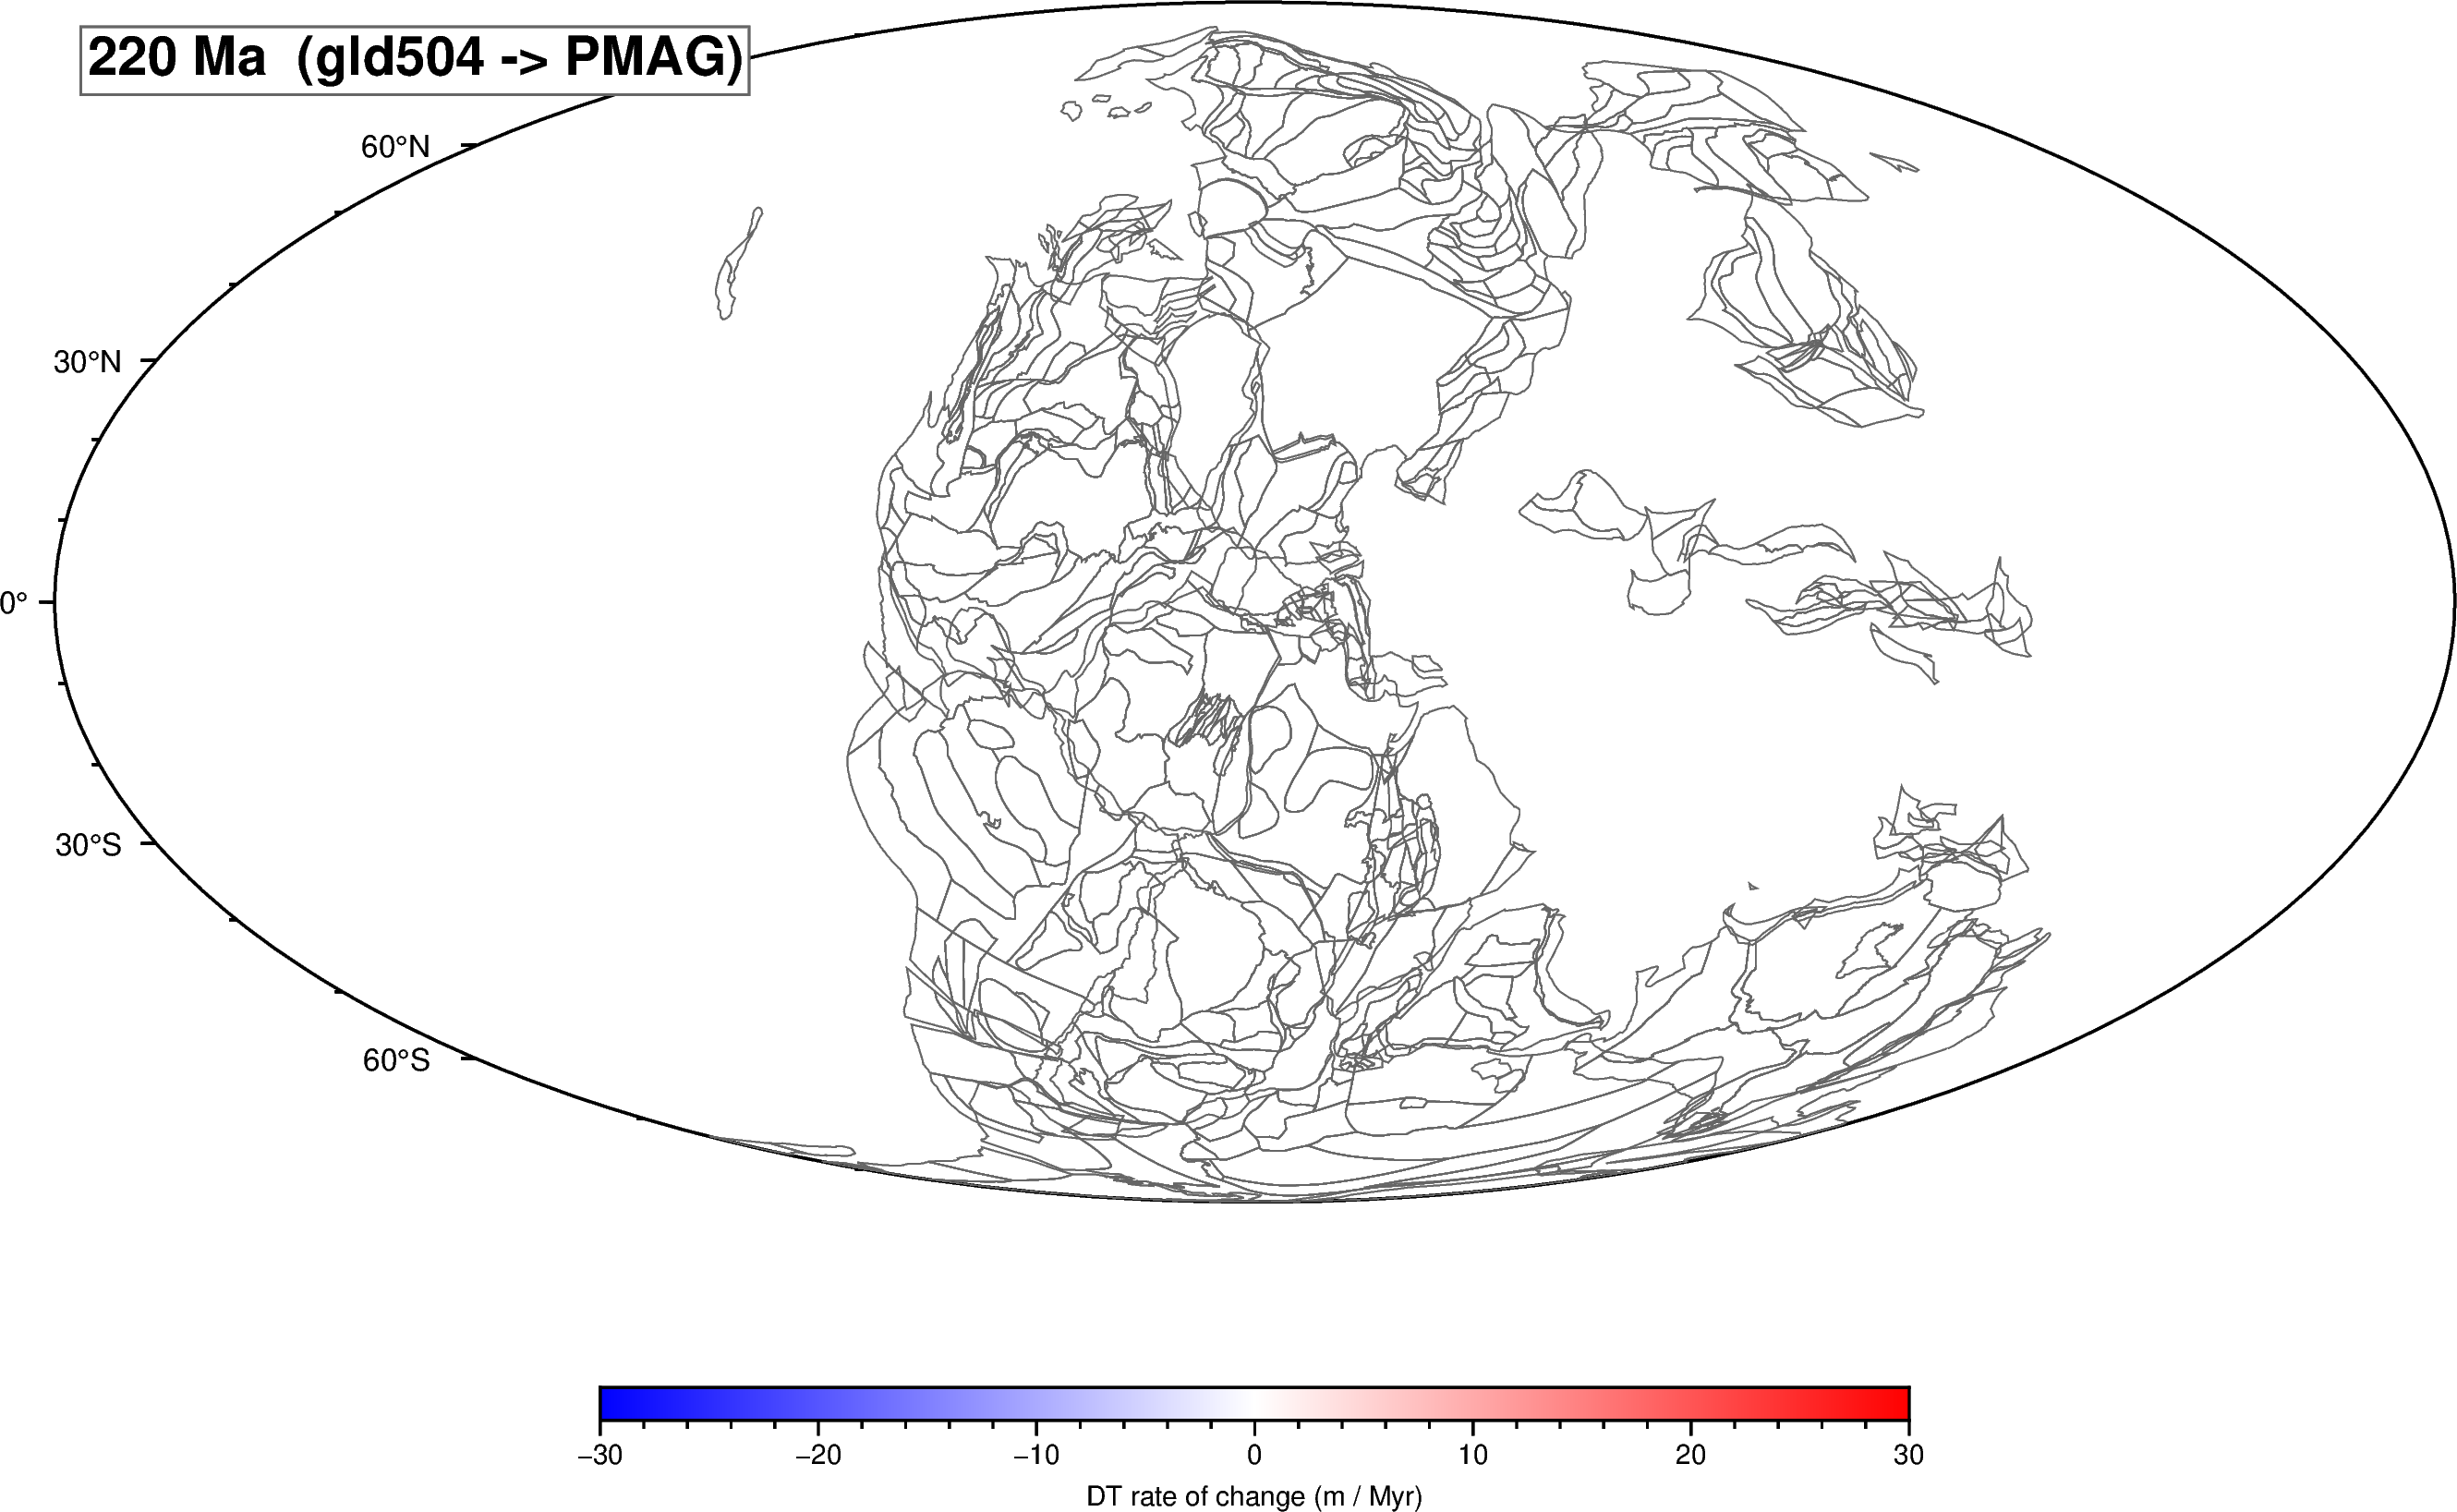

  saved: santosh_pmag_figs/T47_DTrate_220Ma.png


In [7]:
# Final plot — pyGMT, one Figure per panel (house style)
import pygmt

def render_panel(da, title, cpt_series, cpt_name, age, tag):
    da = da.copy()
    da.gmt.registration = 0
    da.gmt.gtype = 1
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    pygmt.makecpt(cmap=cpt_name, series=list(cpt_series), continuous=True,
                  background="o")
    fig.grdimage(grid=da, cmap=True, nan_transparent=True)
    # Coastline / plate-boundary overlay from gld504 + COB
    gplot = gplately.PlotTopologies(
        plate_reconstruction=gld504_reconstruction_model,
        coastlines=None,                  # gld504 doesn't ship coastlines
        continents=_static_polyg,
        COBs=_cob,
        time=float(age))
    engine = gplately.PygmtPlotEngine()
    try:
        engine.plot_geo_data_frame(fig, gplot.get_continents(),
                                   pen="0.35p,gray40")
    except Exception:
        pass
    try:
        engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                                   pen="0.6p,indianred")
    except Exception:
        pass
    fig.colorbar(frame=[f"af+l{title}"],
                 position="JBC+w12c/0.3c+h+o0/1.7c")
    fig.text(text=f"{age:.0f} Ma  ({GLD_ID} -> PMAG)",
             position="TL", offset="0.3c/-0.3c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    out = SAVE_FIG_DIR / f"T47_{tag}_{int(age)}Ma.png"
    fig.savefig(out, dpi=200)
    fig.show(width=1200)
    display(HTML('<div style="height:1cm"></div>'))
    print(f"  saved: {out}")
    return fig


# DT snapshots
for age in PMAG_AGES:
    render_panel(pmag_DT[age],
                 title="Dynamic topography (m)",
                 cpt_series=[-1500, 1500, 50],
                 cpt_name="polar",
                 age=age,
                 tag="DT")

# DT rate of change snapshots
for age in PMAG_AGES:
    render_panel(pmag_DT_rate[age],
                 title="DT rate of change (m / Myr)",
                 cpt_series=[-30, 30, 1],
                 cpt_name="polar",
                 age=age,
                 tag="DTrate")


## What this notebook shows

The PMAG-frame snapshots place the gld504-driven dynamic topography +
DT-rate fields at the paleo-positions inferred from paleomagnetism rather
than from absolute mantle reference frames. This is the right view to use
when comparing modelled DT against paleoclimate proxies or
paleobiogeographic distributions, both of which sit naturally in the
paleomagnetic frame (see CLAUDE.md's strict paleomag-frame rule).

The 540 Ma and 220 Ma snapshots capture two reference epochs in the
Dhungana & Flament 2026 (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) narrative: the late Neoproterozoic / early
Cambrian (close to the Great Unconformity formation window in many
Laurentian sections), and the late Pangea / Early Triassic.

## Extend this
- Add 100 Ma + 50 Ma snapshots — the same machinery works at any age the
  gld504 chain covers (1000-0 Ma).
- Swap PALEOMAP (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) for the Z22 paleomag frame (CLAUDE.md default for 0-410 Ma)
  to compare the choice of PMAG model. The reconstruction calls are
  rotation-model-agnostic.
- Overlay paleoclimate proxies (T38 Köppen-Geiger belts, T39 HadCM3 SST,
  T42 cGENIE (https://github.com/derpycode/cgenie.muffin)) on these PMAG-frame DT snapshots for a directly-comparable
  view of mantle vs surface signals.
- Compute and overlay the DT-rate transient at higher temporal resolution
  (e.g. 10 Myr steps) to see whether the long-term-trend signal seen here
  has fine-scale episodicity.

## Citation
- Dhungana, S. & Flament, N. (2026, under review). *Dynamic topography
  and the Great Unconformity.*
- Source notebook: Santosh Dhungana, `Paleoelev_DT_DTrate_Reconstruction_PMAG.ipynb`,
  shared 2026-06-18.
- Merdith, A.S. et al. (2021). *Extending full-plate tectonic models into
  deep time*. Earth-Science Reviews 214, 103477.
- PALEOMAP / Scotese plate model: Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/).

## Source-port note

The original notebook download was truncated mid-base64-image (the final
plot cell's *output*, not its source code; the workflow port above is
complete). The pyGMT plot at the bottom is written fresh in the suite
house style and may differ visually from the source. Once a complete copy
of the source notebook is in hand we can audit the plot block for parity.
